In [100]:
!pip install mlflow dagshub -q

import numpy as np
import pandas as pd
import os
import mlflow
import mlflow.sklearn
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

def reduce_mem_usage(df):
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    return df

In [101]:
import dagshub
dagshub.init(repo_owner='Sula1909', repo_name='ML-Assignment2', mlflow=True)

mlflow.set_tracking_uri("https://dagshub.com/Sula1909/ML-Assignment2.mlflow")

mlflow.set_experiment("XGBoost_Training")

Initialized MLflow to track repo "Sula1909/ML-Assignment2"

Repository Sula1909/ML-Assignment2 initialized!

<Experiment: artifact_location='mlflow-artifacts:/3f39636511fe40c89becc667203bd5f9', creation_time=1777654084520, experiment_id='0', last_update_time=1777654084520, lifecycle_stage='active', name='XGBoost_Training', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [102]:
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.expand_frame_repr', False)

In [103]:
print("Loading data...")
train_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
train_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

test_trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv')
test_id = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv')

train = pd.merge(train_trans, train_id, on='TransactionID', how='left')
test = pd.merge(test_trans, test_id, on='TransactionID', how='left')

train = reduce_mem_usage(train)
test = reduce_mem_usage(test)

del train_trans, train_id, test_trans, test_id
print(f"Dataset shape: {train.shape}")
print(f"Dataset shape: {test.shape}")

Loading data...


/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_57/2337643808.py:28: RuntimeWarning: overfl

Dataset shape: (590540, 434)
Dataset shape: (506691, 433)


In [104]:
train.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [105]:
na_rate = train.isna().mean()
print(na_rate[na_rate > 0.1].sort_values(ascending=False).to_string())

id_24            0.991962
id_25            0.991310
id_07            0.991271
id_08            0.991271
id_21            0.991264
id_26            0.991257
id_22            0.991247
id_23            0.991247
id_27            0.991247
dist2            0.936284
D7               0.934099
id_18            0.923607
D13              0.895093
D14              0.894695
D12              0.890410
id_04            0.887689
id_03            0.887689
D6               0.876068
id_33            0.875895
D9               0.873123
D8               0.873123
id_09            0.873123
id_10            0.873123
id_30            0.868654
id_32            0.868619
id_34            0.868248
id_14            0.864456
V138             0.861237
V141             0.861237
V140             0.861237
V157             0.861237
V149             0.861237
V146             0.861237
V139             0.861237
V142             0.861237
V155             0.861237
V154             0.861237
V153             0.861237
V161        

# EDA & CLEANING

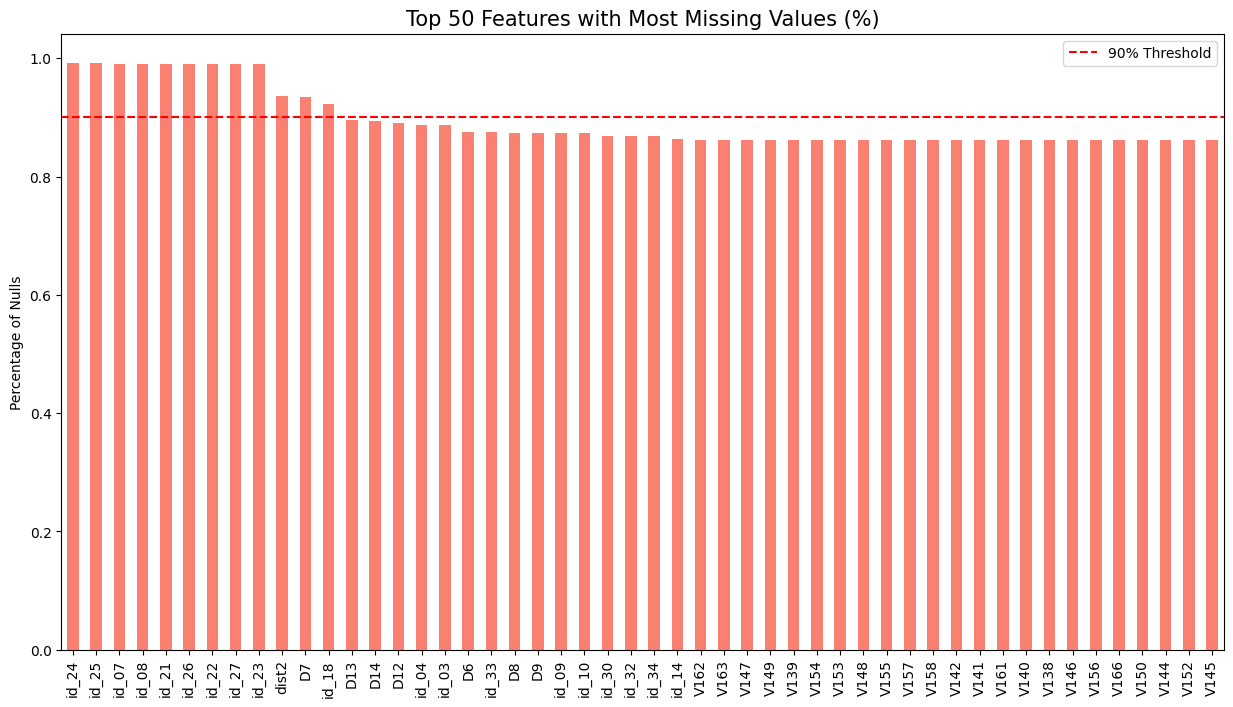

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns

null_data = train.isnull().mean().sort_values(ascending=False)[:50]

plt.figure(figsize=(15, 8))
null_data.plot(kind='bar', color='salmon')
plt.title('Top 50 Features with Most Missing Values (%)', fontsize=15)
plt.ylabel('Percentage of Nulls')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.legend()
plt.show()

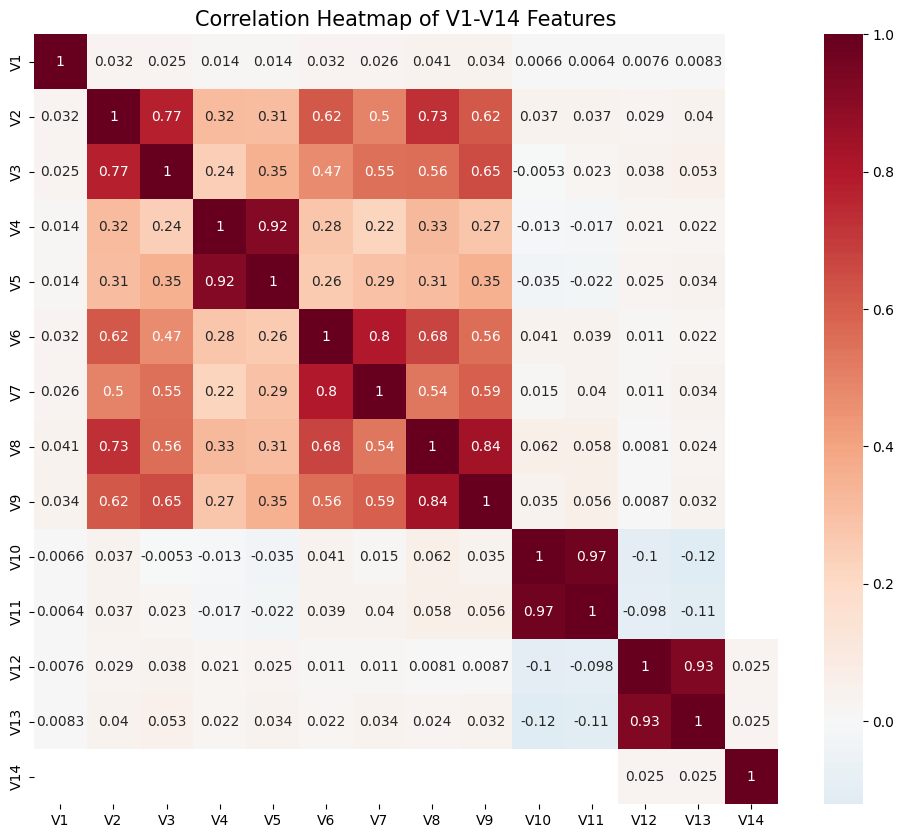

In [107]:
v_cols = [f'V{i}' for i in range(1, 15)]
plt.figure(figsize=(12, 10))
sns.heatmap(train[v_cols].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Correlation Heatmap of V1-V14 Features', fontsize=15)
plt.show()

/tmp/ipykernel_57/2075752320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


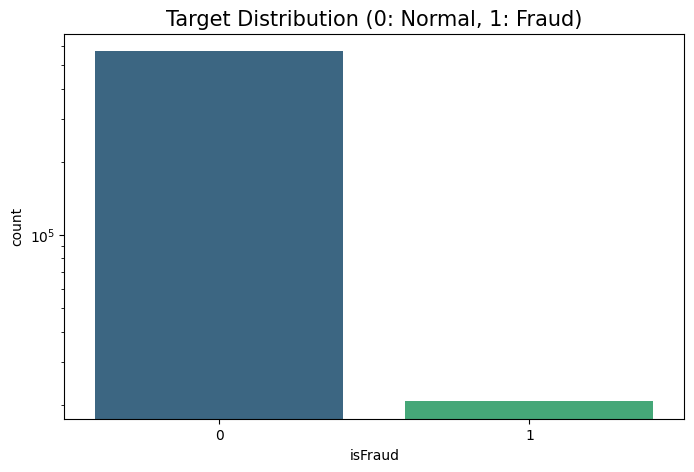

Fraud Percentage: 3.50%


In [108]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y, palette='viridis')
plt.title('Target Distribution (0: Normal, 1: Fraud)', fontsize=15)
plt.yscale('log') # Log Scale
plt.show()

print(f"Fraud Percentage: {y.mean()*100:.2f}%")

In [109]:
train.head()

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

***> TransactionDT Analysis***

In [110]:
print(train['TransactionDT'].dtype)

print(train["TransactionDT"].isnull().sum())

print(train["TransactionDT"].nunique())

int32
0
573349


In [111]:
train[['TransactionDT']].describe().astype(int)

,TransactionDT
count,590540
mean,7372311
std,4617223
min,86400
25%,3027057
50%,7306527
75%,11246620
max,15811131


/tmp/ipykernel_57/1803339530.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['TransactionDT'],kde = False,bins=60)
/tmp/ipykernel_57/1803339530.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(test['TransactionDT'],kde = False,bins=60)


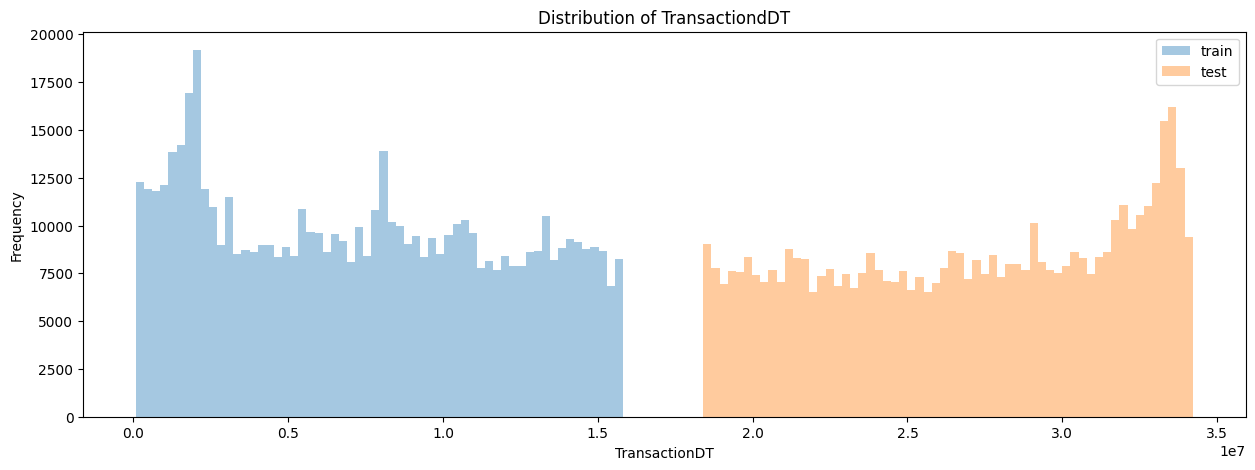

In [112]:
plt.figure(figsize = (15,5))
sns.distplot(train['TransactionDT'],kde = False,bins=60)
sns.distplot(test['TransactionDT'],kde = False,bins=60)
plt.legend(['train', 'test'])
plt.ylabel('Frequency')

plt.title('Distribution of TransactiondDT');
plt.show()

***> TransactionAmt Analysis***

In [113]:
print(train['TransactionAmt'].dtype)

print(train["TransactionAmt"].nunique())

print(train["TransactionAmt"].isnull().sum())
print(test["TransactionAmt"].isnull().sum())

float16
8195
0
0


In [114]:
print(train['TransactionAmt'].describe())
print(" ")
print(test['TransactionAmt'].describe())

count    590540.000000
mean               NaN
std           0.000000
min           0.250977
25%          43.312500
50%          68.750000
75%         125.000000
max       31936.000000
Name: TransactionAmt, dtype: float64
 
count    506691.000000
mean               NaN
std           0.000000
min           0.018005
25%          40.000000
50%          67.937500
75%         125.000000
max       10272.000000
Name: TransactionAmt, dtype: float64


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/pandas/core/na

In [115]:
train[train.TransactionAmt > 30000]

/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
274336,3261336,0,6652360,31936.0,W,16075,514.0,150.0,mastercard,102.0,credit,205.0,87.0,27.0,NaN,yahoo.com,NaN,1.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.0,T,T,T,NaN,NaN,NaN,F,F,T,1.0,3.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1422.390015,1422.390015,1422.390015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,1422.390015,1422.390015,1422.390015,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
274339,3261339,0,6652391,319

***> ProductCD Analysis***

In [116]:
print(train["ProductCD"].dtype)

print(train["ProductCD"].nunique())

print(train["ProductCD"].isnull().sum())
print(test["ProductCD"].isnull().sum())

object
5
0
0


In [117]:
train["ProductCD"].describe()

count     590540
unique         5
top            W
freq      439670
Name: ProductCD, dtype: object

In [118]:
train["ProductCD"].value_counts()

ProductCD
W    439670
C     68519
R     37699
H     33024
S     11628
Name: count, dtype: int64

/tmp/ipykernel_57/683254693.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')
/tmp/ipykernel_57/683254693.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')


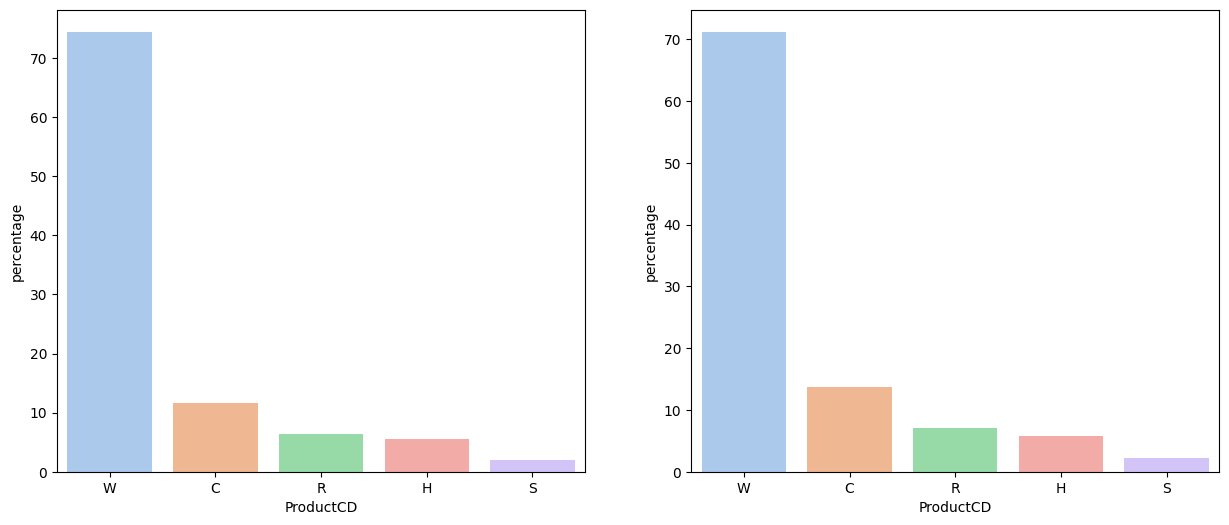

In [119]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
train_ProductCD = train['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = train_ProductCD, palette = 'pastel')

plt.subplot(1,2,2)
test_ProductCD = test['ProductCD'].value_counts(normalize=True).mul(100).rename('percentage')\
.reset_index()
sns.barplot(x = "ProductCD", y = "percentage", data = test_ProductCD, palette = 'pastel')

plt.show();

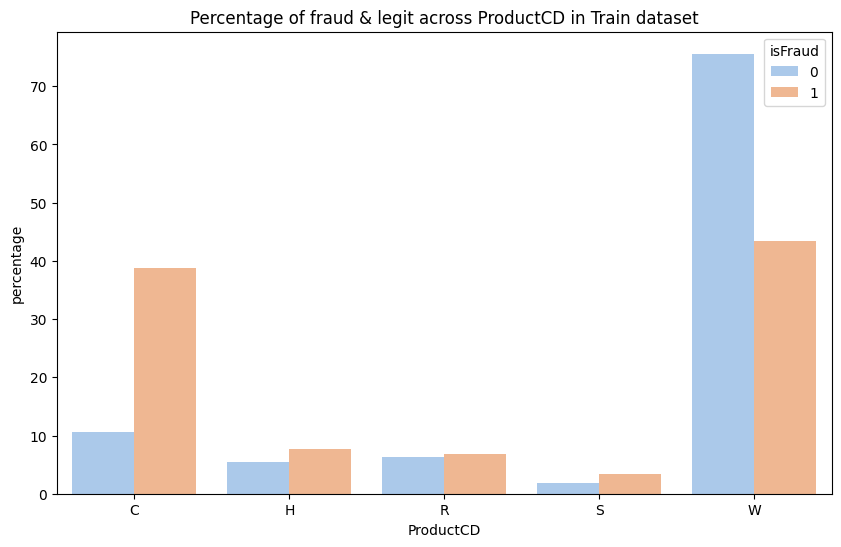

In [120]:
plt.figure(figsize = (10,6))

train_ProductCD = (train.groupby(['isFraud'])['ProductCD'].value_counts(normalize = True).rename('percentage').mul(100).reset_index().sort_values('ProductCD'))

sns.barplot(x = "ProductCD", y = "percentage", hue = "isFraud", data = train_ProductCD, palette = 'pastel')

plt.title('Percentage of fraud & legit across ProductCD in Train dataset')

plt.show();

***> DeviceType & DeviceInfo Analysis***

In [121]:
print(train["DeviceType"].dtype)

print(train['DeviceType'].isnull().sum())

print(train['DeviceType'].unique())

object
449730
[nan 'mobile' 'desktop']


In [122]:
train['DeviceType'].describe()

count      140810
unique          2
top       desktop
freq        85165
Name: DeviceType, dtype: object

In [123]:
train['DeviceType'].value_counts()

DeviceType
desktop    85165
mobile     55645
Name: count, dtype: int64

/tmp/ipykernel_57/3547096603.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')


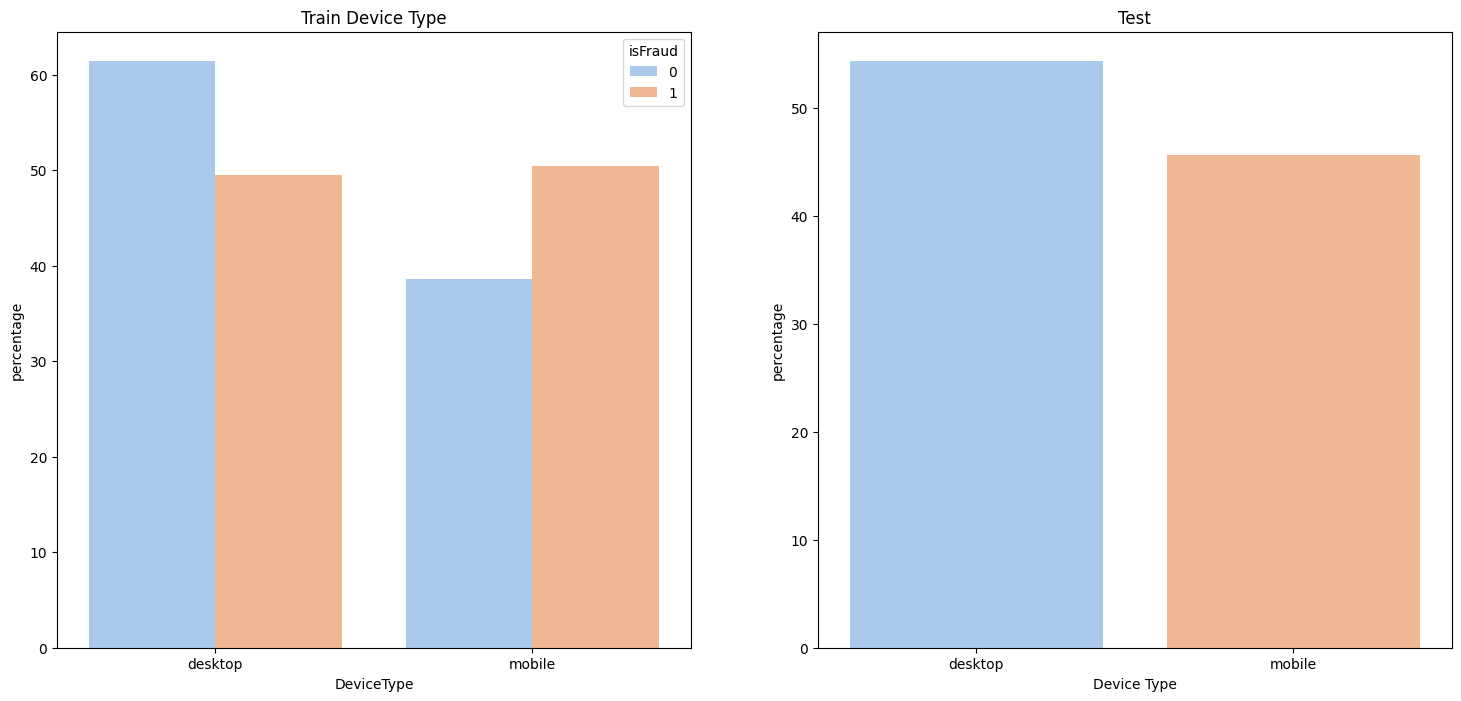

In [124]:
plt.figure(figsize = (18,8))

plt.subplot(1,2,1)

train_DeviceType = (train[~train['DeviceType'].isnull()].groupby(['isFraud'])['DeviceType'].value_counts(normalize=True).rename('percentage').mul(100).reset_index().sort_values('DeviceType'))
sns.barplot(x = "DeviceType", y = "percentage", hue = "isFraud", data = train_DeviceType, palette = 'pastel')
plt.title('Train Device Type')

plt.subplot(1,2,2)

test_DeviceType = test[~test['DeviceType'].isnull()]['DeviceType'].value_counts(normalize = True).mul(100).rename('percentage').reset_index()

sns.barplot( x = "DeviceType", y = "percentage", data=test_DeviceType, palette = 'pastel')
plt.xlabel('Device Type')
plt.title('Test')

plt.show()

In [125]:
print(train["DeviceInfo"].dtype)

print(train['DeviceInfo'].isnull().sum())

print(train['DeviceInfo'].unique())

object
471874
[nan 'SAMSUNG SM-G892A Build/NRD90M' 'iOS Device' ...
 'LDN-LX3 Build/HUAWEILDN-LX3' 'Z955A' 'LG-E975']


In [126]:
train["DeviceInfo"].describe()

count      118666
unique       1786
top       Windows
freq        47722
Name: DeviceInfo, dtype: object

In [127]:
train['DeviceInfo'].value_counts()[:5]

DeviceInfo
Windows        47722
iOS Device     19782
MacOS          12573
Trident/7.0     7440
rv:11.0         1901
Name: count, dtype: int64

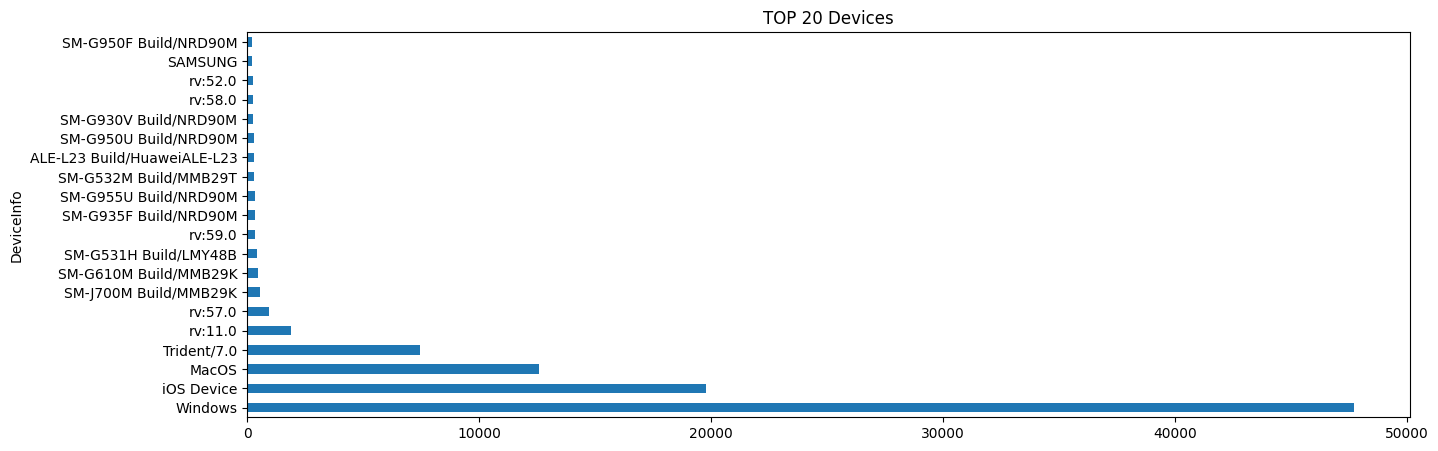

In [128]:
train.groupby('DeviceInfo') \
    .count()['TransactionID'] \
    .sort_values(ascending = False) \
    .head(20) \
    .plot(kind = 'barh', figsize = (15 , 5), title = 'TOP 20 Devices')
    
plt.show()

# Feature Engineering

In [129]:
train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1

test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1

/tmp/ipykernel_57/2737070471.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['day'] = ((train['TransactionDT'] //(3600*24)-1)%7)+1
/tmp/ipykernel_57/2737070471.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['day'] = ((test['TransactionDT'] //(3600*24)-1)%7)+1


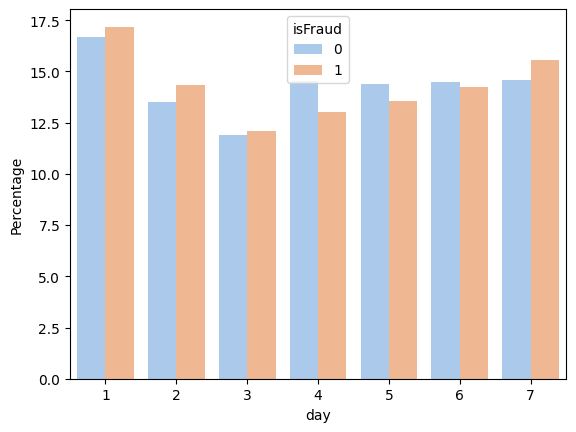

In [130]:
train_days = (train.groupby(['isFraud'])['day']
                     .value_counts(normalize=True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('day'))
sns.barplot(x="day", y = "Percentage", hue="isFraud", data = train_days, palette = 'pastel')
plt.show();

In [131]:
train['hour'] = ((train['TransactionDT']//3600)%24)+1

test['hour'] = ((test['TransactionDT']//3600)%24)+1

/tmp/ipykernel_57/1202968795.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour'] = ((train['TransactionDT']//3600)%24)+1
/tmp/ipykernel_57/1202968795.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour'] = ((test['TransactionDT']//3600)%24)+1


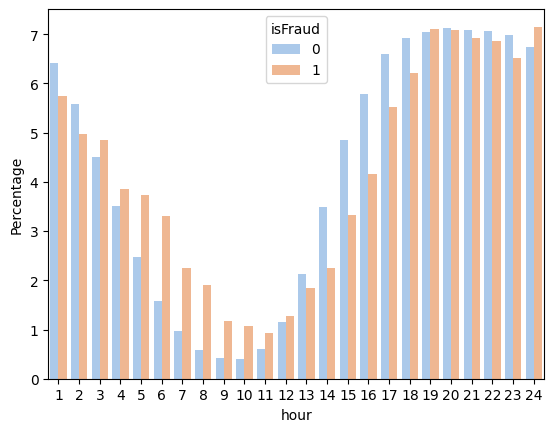

In [132]:
train_hour = (train.groupby(['isFraud'])['hour']
                     .value_counts(normalize = True)
                     .rename('Percentage')
                     .mul(100)
                     .reset_index()
                     .sort_values('hour'))
sns.barplot(x = "hour", y = "Percentage", hue = "isFraud", data = train_hour, palette = 'pastel')
plt.show();

In [133]:
def hourFeature(hour):
    if hour > 4 and hour < 12:
        return "highalert"
    if hour ==12 or hour==19:
        return "lowalert"
    if hour==3 or hour==4 or hour==24:
        return "mediumalert"
    else:
        return "noalert"


train['hour_alertFeature'] = train['hour'].apply(hourFeature)

test['hour_alertFeature'] = test['hour'].apply(hourFeature)

/tmp/ipykernel_57/1786035222.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train['hour_alertFeature'] = train['hour'].apply(hourFeature)
/tmp/ipykernel_57/1786035222.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test['hour_alertFeature'] = test['hour'].apply(hourFeature)


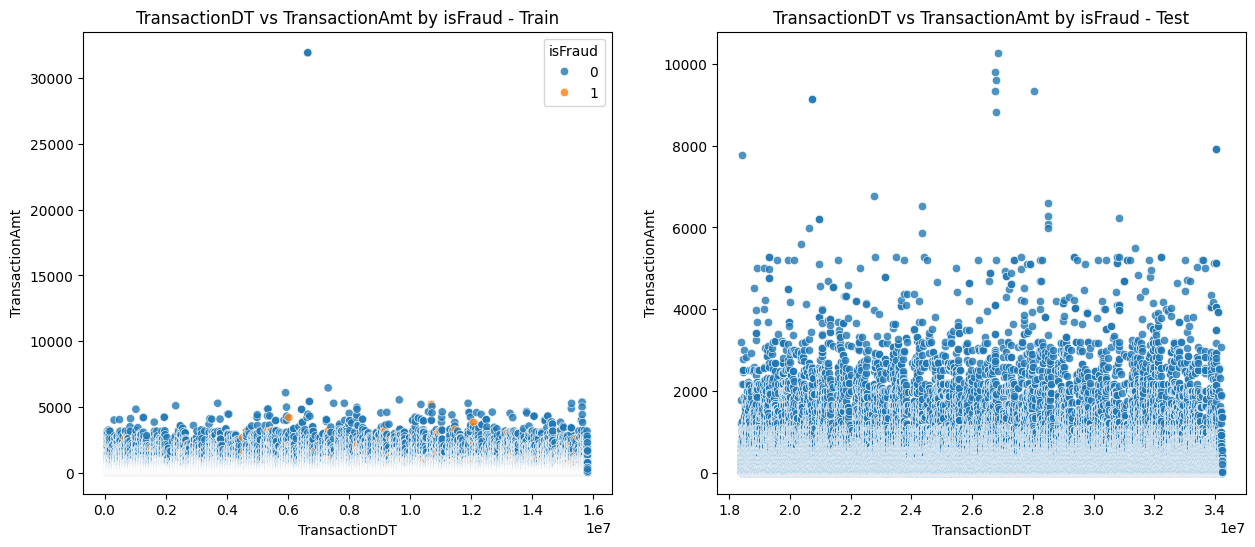

In [134]:
plt.figure(figsize = (15,6))
plt.subplot(1,2,1)
g1 = sns.scatterplot(x = "TransactionDT", y = "TransactionAmt", hue = "isFraud", data = train, alpha = 0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Train')
plt.subplot(1,2,2)
sns.scatterplot(x = "TransactionDT",y="TransactionAmt", data=test, alpha=0.8, hue_order = [0,1])

plt.title('TransactionDT vs TransactionAmt by isFraud - Test')
plt.show()

In [135]:
# Remove 2 TransactionAmt Outliers.
train = train[train['TransactionAmt'] < 30000]

# Models

In [136]:
y = train['isFraud']
X = train.drop(columns=['isFraud', 'TransactionID'])

results_df = pd.DataFrame(columns=['Run Name', 'Estimators', 'Max Depth', 'Learning Rate', 'AUC Score', 'Notes'])

In [137]:
run_baseline = False  

if run_baseline:
    
    # Preprocessing 
    X_numeric = X.select_dtypes(include=['number'])
    X_numeric = X_numeric.fillna(-999)

    X_train, X_val, y_train, y_val = train_test_split(
        X_numeric, y, test_size=0.2, random_state=42, stratify=y
    )

    del X_numeric
    gc.collect()

    params = {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": 'hist',
        "device": 'cuda',
        "random_state": 42
    }

    
    with mlflow.start_run(run_name="XGBoost_Baseline"):
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred_proba)
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)
        mlflow.sklearn.log_model(model, "xgboost_baseline_model")

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Baseline",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'Numeric only, fillna(-999)'
        }])
        
        if 'results_df' not in locals():
            results_df = new_result
        else:
            results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model
    gc.collect()
    
else:
    print("XGBoost_Baseline is skipped !")

if 'results_df' in locals():
    display(results_df)

XGBoost_Baseline is skipped !


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [138]:
run_categorical = False 

if run_categorical:
    
    X_cat = X.copy()
    
    # Label Encoding 
    from sklearn.preprocessing import LabelEncoder
    obj_cols = X_cat.select_dtypes(include=['object']).columns
    
    for col in obj_cols:
        le = LabelEncoder()
        X_cat[col] = le.fit_transform(X_cat[col].astype(str))
    
    X_cat = X_cat.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(
        X_cat, y, test_size=0.2, random_state=42, stratify=y
    )

    params = {
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "tree_method": 'hist',
        "device": 'cuda',
        "random_state": 42
    }

    with mlflow.start_run(run_name="XGBoost_Categorical"):
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        y_pred_proba = model.predict_proba(X_val)[:, 1]
        auc_score = roc_auc_score(y_val, y_pred_proba)
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Categorical",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'All features, LabelEncoding on Objects'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"✅ Finished! AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_cat
    import gc
    gc.collect()

else:
    print("XGBoost_Categorical is skipped!")

display(results_df)

XGBoost_Categorical is skipped!


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [139]:
run_cleaning = False

if run_cleaning:
    X_clean = X.copy()
    
    na_rate = X_clean.isna().mean()
    cols_to_drop_nulls = na_rate[na_rate > 0.90].index.tolist() # 0.90 null threshold
    X_clean = X_clean.drop(columns=cols_to_drop_nulls)

    # Label Encoding 
    from sklearn.preprocessing import LabelEncoder
    for col in X_clean.select_dtypes(include=['object']).columns:
        X_clean[col] = LabelEncoder().fit_transform(X_clean[col].astype(str))

    # Correlation Filter 
    corr_matrix = X_clean.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_clean = X_clean.drop(columns=to_drop_corr)

    print(f"Dropped: {len(cols_to_drop_nulls)} (High Nulls), {len(to_drop_corr)} (High Corr)")
    print(f"Remaining features: {X_clean.shape[1]}")

    X_clean = X_clean.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)

    with mlflow.start_run(run_name="XGBoost_Cleaning"):
        params = {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "tree_method": 'hist',
            "device": 'cuda',
            "random_state": 42
        }
        
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        
        auc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

        mlflow.log_params(params)
        mlflow.log_param("features_count", X_clean.shape[1])
        
        mlflow.log_metric("auc", auc_score)

        mlflow.sklearn.log_model(model, "model")
        
        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Cleaning",
            'Estimators': params["n_estimators"],
            'Max Depth': params["max_depth"],
            'Learning Rate': params["learning_rate"],
            'AUC Score': round(auc_score, 4),
            'Notes': 'Dropped Nulls>90% & Corr>0.95'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_clean
    import gc
    gc.collect()

display(results_df)

,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes


In [140]:
run_cleaning_final = False

if run_cleaning_final:

    X_final = train.drop(columns=['isFraud', 'TransactionID']).copy()
    y_final = train['isFraud']
    
    nan_rate = X_final.isna().mean()
    cols_to_drop = nan_rate[nan_rate > 0.80].index.tolist()
    
    for col in X_final.columns:
        if X_final[col].nunique() <= 1:
            cols_to_drop.append(col)
        else:
            top_val_share = X_final[col].value_counts(normalize=True).values[0]
            if top_val_share > 0.95:
                cols_to_drop.append(col)
    
    cols_to_drop = list(set(cols_to_drop))
    X_final = X_final.drop(columns=cols_to_drop)
    print(f"Dropped {len(cols_to_drop)} useless columns.")

    for col in ['card1', 'addr1']:
        if col in X_final.columns:
            if X_final[col].dtype == 'float16':
                X_final[col] = X_final[col].astype('float32')
            vc = X_final[col].value_counts().to_dict()
            X_final[f'{col}_count'] = X_final[col].map(vc)

    from sklearn.preprocessing import LabelEncoder
    for col in X_final.select_dtypes(include=['object']).columns:
        X_final[col] = LabelEncoder().fit_transform(X_final[col].astype(str))
    
    X_final = X_final.fillna(-999)
    X_train, X_val, y_train, y_val = train_test_split(X_final, y_final, test_size=0.2, random_state=42, stratify=y_final)

    with mlflow.start_run(run_name="XGBoost_Cleaning_Final"):
        params = {
            "n_estimators": 500,
            "max_depth": 6,
            "learning_rate": 0.05,
            "tree_method": 'hist',
            "device": 'cuda',
            "random_state": 42
        }
        
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        
        auc_score = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        
        mlflow.log_params(params)
        mlflow.log_metric("auc", auc_score)
        mlflow.log_param("dropped_cols", len(cols_to_drop))

        mlflow.sklearn.log_model(model, "model")

        new_result = pd.DataFrame([{
            'Run Name': "XGBoost_Cleaning_Final",
            'Estimators': 500, 'Max Depth': 6, 'Learning Rate': 0.05,
            'AUC Score': round(auc_score, 4),
            'Notes': 'Maximum of just cleaning'
        }])
        results_df = pd.concat([results_df, new_result], ignore_index=True)

    print(f"AUC: {auc_score:.4f}")
    
    del X_train, X_val, y_train, y_val, model, X_final
    import gc
    gc.collect()

display(results_df)

Dropped 142 useless columns.


2026/05/01 23:40:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 23:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/tmp/ipykernel_57/1531417786.py:64: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_result], ignore_index=True)


🏃 View run XGBoost_Cleaning_Final at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/0/runs/824d4f62f5f0457086586c206dd5e274
🧪 View experiment at: https://dagshub.com/Sula1909/ML-Assignment2.mlflow/#/experiments/0
AUC: 0.9436


,Run Name,Estimators,Max Depth,Learning Rate,AUC Score,Notes
0,XGBoost_Cleaning_Final,500,6,0.05,0.9436,Maximum of just cleaning
